# Open WOD datasets

In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import glob
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

### Open datasets and standardize depths

In [ ]:
# ctd_filenames = glob.glob("/Users/mzahn/data/SASSIE/WOD/raw_depths/CTD/*wod*")
# ctd_filenames = glob.glob("/Users/mzahn/data/SASSIE/WOD/raw_depths/APB/*wod*")
# ctd_filenames = glob.glob("/Users/mzahn/data/SASSIE/WOD/raw_depths/DRB/*wod*") # drifting buoy
# ctd_filenames = glob.glob("/Users/mzahn/data/SASSIE/WOD/raw_depths/OSD/*wod*")
ctd_filenames = glob.glob("/Users/mzahn/data/SASSIE/WOD/raw_depths/PFL/*wod*") # profiling float
# print(ctd_filenames)

# new z coordinate
z_coords = np.arange(0,100,0.5)

# loop through each file, open it, standardize depths, and save new ds
for file in ctd_filenames:
    ds = xr.open_dataset(file)

    # ds.Salinity.plot(y='z')
    # plt.ylim(100,0)
    
    # interpolate all variables along the z dimension
    ds_interp = ds.interp(z=z_coords)

    # keep only Temperature and Salinity (if they exist in the dataset)
    keep_vars = [v for v in ["Temperature", "Salinity"] if v in ds_interp.data_vars]
    ds_filtered = ds_interp[keep_vars]

    # preserve coordinates like lat, lon, time
    for coord in ds_interp.coords:
        if coord not in ds_filtered.coords:
            ds_filtered = ds_filtered.assign_coords({coord: ds_interp[coord]})

    # expand to include time as a dimension (if applicable)
    ds_new = ds_filtered.expand_dims(time=[ds_interp.time.values])

    # define new path and save
    new_path = file.replace('/raw_depths/', '/standardized_depths/').replace('.nc', '_standard_depths.nc')
    ds_new.to_netcdf(new_path)

    ds.close()
    ds_new.close()
    
    print(f"Saved standardized dataset: {new_path}")

In [41]:
# ctd_ds = xr.open_mfdataset('/Users/mzahn/data/SASSIE/WOD/standardized_depths/CTD/*.nc')
# drb_ds = xr.open_mfdataset('/Users/mzahn/data/SASSIE/WOD/standardized_depths/DRB/*.nc')
# osd_ds = xr.open_mfdataset('/Users/mzahn/data/SASSIE/WOD/standardized_depths/OSD/*.nc')
# pfl_ds = xr.open_mfdataset('/Users/mzahn/data/SASSIE/WOD/standardized_depths/PFL/*.nc')
apb_ds = xr.open_mfdataset('/Users/mzahn/data/SASSIE/WOD/standardized_depths/APB/*.nc')

(100.0, 0.0)

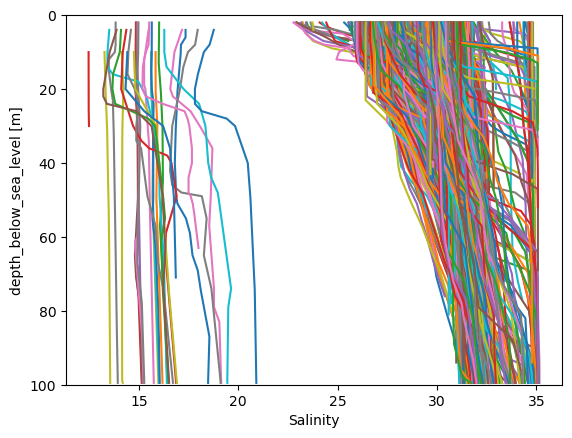

In [45]:
apb_ds.Salinity.plot(hue='time',y='z',add_legend=False)
plt.ylim(100,0)

### Plot locations

In [9]:
ctd_ds = xr.open_mfdataset('/Users/mzahn/data/SASSIE/WOD/raw_depths/CTD/*.CTD.nc')
drb_ds = xr.open_mfdataset('/Users/mzahn/data/SASSIE/WOD/raw_depths/DRB/*.DRB.nc')
osd_ds = xr.open_mfdataset('/Users/mzahn/data/SASSIE/WOD/raw_depths/OSD/*.OSD.nc')
pfl_ds = xr.open_mfdataset('/Users/mzahn/data/SASSIE/WOD/raw_depths/PFL/*.PFL.nc')
apb_ds = xr.open_mfdataset('/Users/mzahn/data/SASSIE/WOD/raw_depths/APB/*.APB.nc')

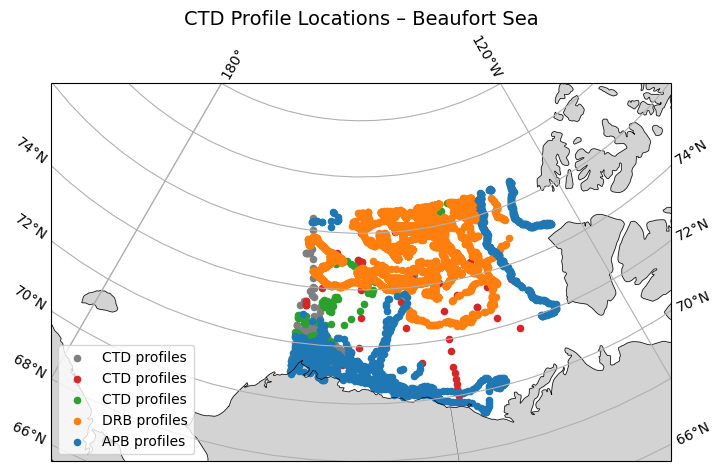

In [11]:
# define projection centered at 150°W
proj = ccrs.NorthPolarStereo(central_longitude=-150)

# create figure and axis
fig = plt.figure(figsize=(8, 8))
ax = plt.axes(projection=proj)

# Beaufort Sea extent [lon_min, lon_max, lat_min, lat_max]
ax.set_extent([-180, -120, 68, 80], crs=ccrs.PlateCarree())

# add map features
ax.add_feature(cfeature.LAND, color='lightgray')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.2)
ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)

# plot CTD profile locations
ax.scatter(
    ctd_ds.lon,
    ctd_ds.lat,
    s=20,
    color='tab:gray',
    # edgecolor='white',
    transform=ccrs.PlateCarree(),
    label='CTD profiles'
)

ax.scatter(
    osd_ds.lon,
    osd_ds.lat,
    s=20,
    color='tab:red',
    # edgecolor='white',
    transform=ccrs.PlateCarree(),
    label='CTD profiles'
)

ax.scatter(
    pfl_ds.lon,
    pfl_ds.lat,
    s=20,
    color='tab:green',
    # edgecolor='white',
    transform=ccrs.PlateCarree(),
    label='CTD profiles'
)

ax.scatter(
    drb_ds.lon,
    drb_ds.lat,
    s=20,
    color='tab:orange',
    # edgecolor='white',
    transform=ccrs.PlateCarree(),
    label='DRB profiles'
)

ax.scatter(
    apb_ds.lon,
    apb_ds.lat,
    s=20,
    color='tab:blue',
    # edgecolor='white',
    transform=ccrs.PlateCarree(),
    label='APB profiles'
)


# add legend and title
ax.legend(loc='lower left')
ax.set_title('CTD Profile Locations – Beaufort Sea', fontsize=14)

plt.show()

### Calculate MLD

In [26]:
ctd_ds = xr.open_mfdataset('/Users/mzahn/data/SASSIE/WOD/standardized_depths/CTD/*.nc')
drb_ds = xr.open_mfdataset('/Users/mzahn/data/SASSIE/WOD/standardized_depths/DRB/*.nc')
osd_ds = xr.open_mfdataset('/Users/mzahn/data/SASSIE/WOD/standardized_depths/OSD/*.nc')
pfl_ds = xr.open_mfdataset('/Users/mzahn/data/SASSIE/WOD/standardized_depths/PFL/*.nc')
apb_ds = xr.open_mfdataset('/Users/mzahn/data/SASSIE/WOD/standardized_depths/APB/*.nc')

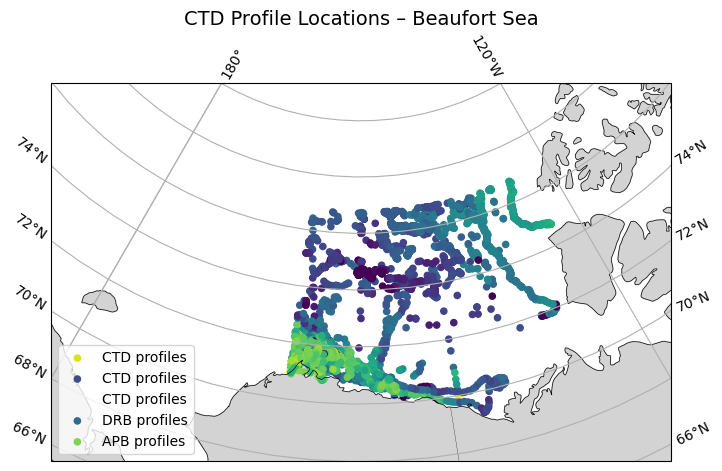

In [32]:
# define projection centered at 150°W
proj = ccrs.NorthPolarStereo(central_longitude=-150)

# create figure and axis
fig = plt.figure(figsize=(8, 8))
ax = plt.axes(projection=proj)

# Beaufort Sea extent [lon_min, lon_max, lat_min, lat_max]
ax.set_extent([-180, -120, 68, 80], crs=ccrs.PlateCarree())

# add map features
ax.add_feature(cfeature.LAND, color='lightgray')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.2)
ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)

# plot CTD profile locations
ax.scatter(
    ctd_ds.lon,
    ctd_ds.lat,
    s=20,
    c=ctd_ds.Salinity.sel(z=slice(0,10)).mean('z'),
    vmin=25,vmax=32,
    transform=ccrs.PlateCarree(),
    label='CTD profiles'
)

ax.scatter(
    osd_ds.lon,
    osd_ds.lat,
    s=20,
    c=osd_ds.Salinity.sel(z=slice(0,10)).mean('z'),
    vmin=25,vmax=32,
    transform=ccrs.PlateCarree(),
    label='CTD profiles'
)

ax.scatter(
    pfl_ds.lon,
    pfl_ds.lat,
    s=20,
    c=pfl_ds.Salinity.sel(z=slice(0,10)).mean('z'),
    vmin=25,vmax=32,
    transform=ccrs.PlateCarree(),
    label='CTD profiles'
)

ax.scatter(
    drb_ds.lon,
    drb_ds.lat,
    s=20,
    c=drb_ds.Salinity.sel(z=slice(0,10)).mean('z'),
    vmin=25,vmax=32,
    transform=ccrs.PlateCarree(),
    label='DRB profiles'
)

ax.scatter(
    apb_ds.lon,
    apb_ds.lat,
    s=20,
    c=apb_ds.Salinity.sel(z=slice(0,10)).mean('z'),
    vmin=25,vmax=32,
    transform=ccrs.PlateCarree(),
    label='APB profiles'
)


# add legend and title
ax.legend(loc='lower left')
ax.set_title('CTD Profile Locations – Beaufort Sea', fontsize=14)

plt.show()

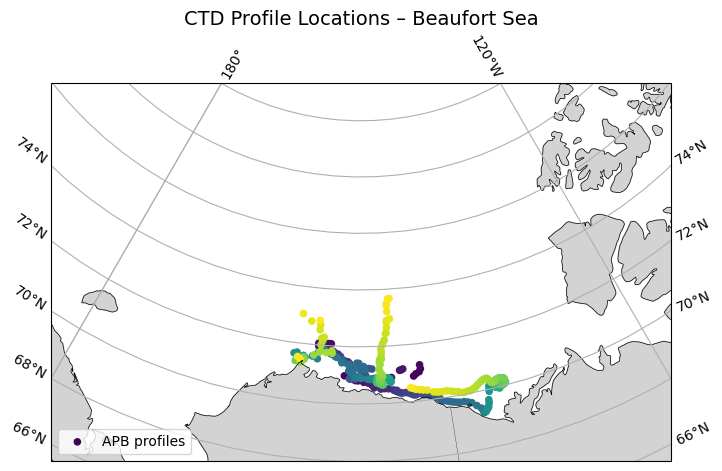

In [64]:
# define projection centered at 150°W
proj = ccrs.NorthPolarStereo(central_longitude=-150)

# create figure and axis
fig = plt.figure(figsize=(8, 8))
ax = plt.axes(projection=proj)

# Beaufort Sea extent [lon_min, lon_max, lat_min, lat_max]
ax.set_extent([-180, -120, 68, 80], crs=ccrs.PlateCarree())

# add map features
ax.add_feature(cfeature.LAND, color='lightgray')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.2)
ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)

# plot CTD profile locations

ax.scatter(
    apb_ds.sel(time='2019-08').lon,
    apb_ds.sel(time='2019-08').lat,
    s=20,
    c=apb_ds.sel(time='2019-08').time,
    # vmin=25,vmax=32,
    transform=ccrs.PlateCarree(),
    label='APB profiles'
)


# add legend and title
ax.legend(loc='lower left')
ax.set_title('CTD Profile Locations – Beaufort Sea', fontsize=14)

plt.show()